## Import

In [20]:
import gym_snakegame
import gymnasium as gym
import numpy as np
import torch.nn as nn
import torch
import gym_snakegame
import matplotlib.pyplot as plt
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Definizione classi e funzioni necessarie per i test

In [21]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()  # Inizializza la classe padre nn.Module
        
        # Definisce la rete neurale con architettura sequenziale:
        # state_dim → 48 → 32 → action_dim
        self.net = nn.Sequential(
            nn.Linear(state_dim, 48),  # Layer fully connected input → hidden
            nn.ReLU(),                 # Funzione di attivazione non lineare
            nn.Linear(48, 32),         # Layer hidden → hidden
            nn.ReLU(),                 # Altra attivazione non lineare
            nn.Linear(32, action_dim)  # Layer hidden → output (Q-values per ogni azione)
        )

    def forward(self, x):
        # Forward pass: calcola l'output della rete dato l'input x
        # Restituisce un tensore di dimensione [batch_size, action_dim]
        # Ogni elemento rappresenta il Q-value stimato per quell'azione
        return self.net(x)

def select_action(model, state, epsilon, act_dim):
    # Funzione epsilon-greedy per la selezione delle azioni
    
    # Exploration: sceglie un'azione casuale con probabilità epsilon
    # epsilon diminuisce tipicamente nel tempo (es. da 1.0 a 0.01)
    if random.random() < epsilon:
        return random.randrange(act_dim)  # Azione casuale tra 0 e act_dim-1
    
    # Exploitation: sceglie l'azione con il Q-value più alto secondo la rete
    with torch.no_grad():  # Disabilita il calcolo dei gradienti per efficienza
        # Converte lo stato in tensore e aggiunge dimensione batch (batch_size=1)
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        
        # 1. model(state): calcola i Q-values per tutte le azioni
        # 2. torch.argmax(...): trova l'indice dell'azione con Q-value massimo
        # 3. .item(): estrae il valore scalare dal tensore
        # 4. int(...): converte in intero
        return int(torch.argmax(model(state)).item())

## Funzioni per l'estrazione delle features

In [22]:
def get_direction(dx, dy):
    """Usa segno per determinare direzione."""
    
    # Converte in -1, 0, +1
    # Normalizza dx e dy a valori di segno: -1 (negativo), 0 (zero), +1 (positivo)
    sign_dx = 0 if dx == 0 else (1 if dx > 0 else -1)
    sign_dy = 0 if dy == 0 else (1 if dy > 0 else -1)
    
    # Lookup table: (sign_dx, sign_dy) → idx
    # Mappa ogni combinazione di segni a un indice di direzione (0-7)
    direction_map = {
        (+1,  0): 0,  # GIÙ      (dx positivo, dy zero)
        (+1, +1): 1,  # GIÙ-DESTRA (dx positivo, dy positivo)
        ( 0, +1): 2,  # DESTRA   (dx zero, dy positivo)
        (-1, +1): 3,  # SU-DESTRA (dx negativo, dy positivo)
        (-1,  0): 4,  # SU       (dx negativo, dy zero)
        (-1, -1): 5,  # SU-SINISTRA (dx negativo, dy negativo)
        ( 0, -1): 6,  # SINISTRA (dx zero, dy negativo)
        (+1, -1): 7,  # GIÙ-SINISTRA (dx positivo, dy negativo)
    }
    
    return direction_map.get((sign_dx, sign_dy), 0)  # Restituisce 0 (GIÙ) come default

def get_features(board):
    """Feature ottimizzate: angolo 8-direzionale + distanza + direzione one-hot."""
    # Se board ha dimensione 3 (batch, altezza, larghezza), rimuovi la dimensione batch
    if len(board.shape) == 3:
        board = board.squeeze(0)
    
    board_size = len(board)  # Dimensione della scacchiera (es. 12x12)
    ITEM = board_size * board_size + 1  # Valore che rappresenta il cibo sulla board
    
    # Inizializza variabili per memorizzare le posizioni chiave
    head = None       # Posizione della testa (valore = 1)
    second = None     # Posizione del secondo segmento (valore = 2)
    food = None       # Posizione del cibo (valore = ITEM)
    tail = None       # Posizione della coda (valore massimo > 2)
    max_body = 0      # Valore massimo trovato (per identificare la coda)
    empty_cells = 0   # Conteggio celle vuote (0) o con cibo (ITEM)
    total_cells = board_size * board_size
    
    # SCANSIONE COMPLETA DELLA BOARD per trovare tutti gli elementi
    for x in range(board_size):
        for y in range(board_size):
            val = board[x, y]
            if val == 1:
                head = (x, y)
            elif val == 2:
                second = (x, y)
            elif val == ITEM:
                food = (x, y)
                empty_cells += 1  # Il cibo conta come cella vuota per il movimento
            elif val > max_body:
                tail = (x, y)
                max_body = val
            elif val == 0:
                empty_cells += 1
    
    # Controlli di validità
    if not head:
        raise ValueError("Testa non individuata")
    if max_body <= 1:
        raise ValueError(f"Individuato max body {max_body} ma dovrebbe essere > 1")
    
    hx, hy = head  # Coordinate della testa
    features = []  # Lista che conterrà tutte le feature estratte

    # FEATURE 0: SPAZIO LIBERO CRITICO
    free_space_ratio = empty_cells / total_cells  # Percentuale di spazio libero
    # Inverte il rapporto: 1.0 quando lo spazio è pieno, 0.0 quando è vuoto
    space_criticality = 1.0 - free_space_ratio
    features.append(space_criticality)  # Feature 1/26
    
    # FEATURE 1-16: RAYCASTING in 8 direzioni (2 feature per direzione)
    directions = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]
    
    warning_score = 0.0  # Punteggio cumulativo di pericolo
    
    for dx, dy in directions:
        content = None   # Tipo di contenuto trovato (-1: muro, 1: cibo, negativo: corpo)
        distance = None  # Distanza normalizzata del primo oggetto
        
        # Esegui raycasting fino al bordo della board
        for step in range(1, board_size+1):
            x, y = hx + dx * step, hy + dy * step
            
            # Controllo uscita dai bordi
            if not (0 <= x < board_size and 0 <= y < board_size):
                if content is None and distance is None:
                    content = -1.0  # Muro
                    distance = step / board_size  # Normalizza: distanza/bordi
                warning_score += 1.0 / step  # Aggiungi penalità (maggiore se vicino)
                break
            
            val = board[x, y]
            if val != 0:  # Cella non vuota
                if content is None and distance is None:
                    distance = step / board_size  # Prima occorrenza
                    if val == ITEM:
                        content = 1.0  # Cibo
                        # Continua a cercare oltre il cibo per pericoli
                        continue
                    elif val > 1:
                        # Pericolo: corpo del serpente
                        # Normalizza: val più alto (vicino alla testa) = più pericoloso
                        danger = 1.0 - (val / max_body)
                        content = -0.8 - (danger * 0.2)  # Valore tra -0.8 e -1.0
                    else:
                        raise ValueError(f"Valore sulla board invalido in posizione ({x},{y}): {val}")
                # Aggiorna warning_score per qualsiasi ostacolo trovato
                warning_score += 1.0 / step
                break
        
        # Verifica che entrambe le feature siano state calcolate
        if content is None or distance is None:
            raise ValueError("Contenuto o distanza non valutati nella logica a step")
        
        # Aggiungi le 2 feature per questa direzione
        features.extend([content, distance])

    # Normalizza warning_score tra 0 e 1 (diviso per numero direzioni)
    warning_score = warning_score / 8.0
    features.append(warning_score)  # Feature 17/26
    
    # FEATURE 18-21: DIREZIONE CORRENTE DEL SERPENTE (one-hot encoding)
    dir_onehot = [0.0, 0.0, 0.0, 0.0]  # [SU, DESTRA, GIÙ, SINISTRA]
    
    if second:
        sx, sy = second
        # Determina direzione basandosi sulla posizione relativa tra testa e secondo segmento
        if sx < hx:    # Secondo SOPRA testa → testa si muove GIÙ
            dir_onehot[2] = 1.0  # GIÙ
        elif sx > hx:  # Secondo SOTTO testa → testa si muove SU
            dir_onehot[0] = 1.0  # SU
        elif sy < hy:  # Secondo SINISTRA testa → testa si muove DESTRA
            dir_onehot[1] = 1.0  # DESTRA
        elif sy > hy:  # Secondo DESTRA testa → testa si muove SINISTRA
            dir_onehot[3] = 1.0  # SINISTRA
    else:
        raise ValueError("Collo del serpente non individuato")
    
    features.extend(dir_onehot)  # Features 18,19,20,21
    
    # FEATURE 22-23: INFORMAZIONE SUL CIBO
    if food:
        fx, fy = food
        dx, dy = fx - hx, fy - hy
        
        direction = get_direction(dx,dy)  # Direzione 8-direzionale (0-7)
        
        # Normalizza direzione a [0, 1)
        food_angle_norm = direction / 8.0
        
        # Distanza Manhattan normalizzata
        # (|dx| + |dy|) / (2 * board_size) → massimo 0.917 (1.0 solo per i muri, raggiungibile nel raycasting)
        food_dist = (abs(dx) + abs(dy)) / (2 * board_size)
        
        features.extend([food_angle_norm, food_dist])  # Features 22,23
    else:
        raise ValueError("Cibo non trovato")
    
    # FEATURE 24-25: INFORMAZIONE SULLA CODA
    if tail:
        tx, ty = tail
        dx, dy = tx - hx, ty - hy
        
        direction = get_direction(dx,dy)  # Direzione 8-direzionale (0-7)

        # Normalizza direzione a [0, 1)
        tail_angle_norm = direction / 8.0
        
        # Distanza Manhattan normalizzata
        # (|dx| + |dy|) / (2 * board_size) → massimo 0.917 (1.0 solo per i muri, raggiungibile nel raycasting)
        tail_dist = (abs(dx) + abs(dy)) / (2 * board_size)
        
        features.extend([tail_angle_norm, tail_dist])  # Features 24,25
    else:
        raise ValueError("Coda non trovata")
        
    # TOTALE FEATURE: 26
    # 1 (spazio critico) + 16 (8 direzioni × 2) + 1 (warning) + 4 (direzione) + 2 (cibo) + 2 (coda)
    
    return np.array(features, dtype=np.float32)  # Converti in array numpy

## Funzione per il test dell'agente addestrato con DQN

In [44]:
def test_trained_agent(model_path, board_size=12, num_episodes=10, render_mode=None, print_enabled=False):
    """
    Carica un modello pre-addestrato e visualizza un numero specificato di partite.
    
    Args:
        model_path (str): Percorso del file .pth contenente i pesi del modello
        board_size (int): Dimensione della mappa di gioco
        num_episodes (int): Numero di partite da visualizzare
    """

    # 1. Configurazione dell'ambiente di gioco con modalità di rendering
    env = gym.make(
        "gym_snakegame/SnakeGame-v0",
        board_size=board_size,
        n_channel=1,
        n_target=1,
        render_mode=render_mode  # Modalità 'human' per visualizzare il gioco
    )

    # 2. Definizione delle dimensioni di osservazione e azione
    obs_dim = 26  # 26 features estratte dalla board
    action_dim = env.action_space.n  # 4 azioni possibili

    # 3. Inizializzazione della rete neurale e caricamento dei pesi salvati
    model = DQN(obs_dim, action_dim).to(DEVICE)

    try:
        # Tentativo di caricamento dei pesi del modello dal file specificato
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    except FileNotFoundError:
        print(f"Errore: Il file '{model_path}' non è stato trovato.")
        return

    model.eval()  # Imposta il modello in modalità valutazione (disabilita dropout/batch normalization)
    print(f"Modello caricato da: {model_path}")
    print(f"Avvio di {num_episodes} partite di test...")

    all_rewards = []  # Lista per memorizzare le ricompense di tutte le partite

    # --- CICLO PRINCIPALE PER GLI EPISODI DI TEST ---
    for i_ep in range(num_episodes):
        state, _ = env.reset()  # Reset dell'ambiente per iniziare una nuova partita
        state = get_features(state)  # Estrazione delle features dallo stato iniziale
        done = False  # Flag che indica se la partita è terminata
        total_reward = 0  # Ricompensa totale accumulata nella partita corrente

        if print_enabled: print(f"\n--- Inizio Partita {i_ep + 1}/{num_episodes} ---")
        elif i_ep % 20 == 0: print(f"\n--- Inizio Partita {i_ep + 1}/{num_episodes} ---")

        steps_without_eating = 0
        # Ciclo per ogni step all'interno della partita
        while not done:
            # Preparazione dello stato per l'input della rete neurale
            # Aggiunge una dimensione batch (unsqueeze(0)) e converte in tensore
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)

            with torch.no_grad():  # Disabilita il calcolo dei gradienti (non necessario durante l'inferenza)
                q_values = model(state_tensor)  # Calcolo dei Q-values per tutte le azioni
                action = q_values.argmax(dim=1).item()  # Selezione dell'azione con Q-value più alto

            # Esecuzione dell'azione selezionata nell'ambiente
            state, reward, terminated, truncated, _ = env.step(action)
            # Aggiornamento degli step che lo snake fa senza mangiare
            if reward==0: steps_without_eating += 1
            else: steps_without_eating = 0
            # Aggiornamento delle features dallo stato nuovo
            state = get_features(state)  
            # Se lo snake non mangia per un numero consecutivo di step elevato, l'episodio termina
            if steps_without_eating == 1000:
                truncated = True
                print(f"\n--- Partita {i_ep + 1}/{num_episodes} terminata forzatamente per looping...---")
            done = terminated or truncated  # Controllo se la partita è terminata
            total_reward += reward  # Aggregazione della ricompensa

            # Opzionale: rallenta leggermente per rendere l'azione più visibile all'occhio umano
            if print_enabled: time.sleep(0.05)

        # Fine dell'episodio corrente
        if print_enabled: print(f"Partita {i_ep + 1} terminata! Reward totale: {total_reward}")
        all_rewards.append(total_reward)  # Salvataggio della ricompensa totale

        # Pausa breve tra una partita e l'altra (opzionale)
        if print_enabled: time.sleep(1.0)

    env.close()  # Chiusura dell'ambiente di gioco
    print("\n--- Partite terminate ---")
    return all_rewards

### Test in render mode 'human'

In [19]:
test_trained_agent("model.pth", board_size=12, num_episodes=5, render_mode="human", print_enabled=True)

Modello caricato da: model.pth
Avvio di 5 partite di test...

--- Inizio Partita 1/5 ---
Partita 1 terminata! Reward totale: 24

--- Inizio Partita 2/5 ---
Partita 2 terminata! Reward totale: 31

--- Inizio Partita 3/5 ---
Partita 3 terminata! Reward totale: 30

--- Inizio Partita 4/5 ---
Partita 4 terminata! Reward totale: 37

--- Inizio Partita 5/5 ---
Partita 5 terminata! Reward totale: 38


[24, 31, 30, 37, 38]

### Simulazioni di Monte Carlo dell'agente addestrato con DQN

In [45]:
returns = test_trained_agent("model.pth", board_size=12, num_episodes=1000, render_mode=None, print_enabled=False)

Modello caricato da: model.pth
Avvio di 1000 partite di test...

--- Inizio Partita 1/1000 ---

--- Inizio Partita 21/1000 ---

--- Inizio Partita 41/1000 ---

--- Inizio Partita 61/1000 ---

--- Inizio Partita 81/1000 ---

--- Inizio Partita 101/1000 ---

--- Inizio Partita 121/1000 ---

--- Inizio Partita 141/1000 ---

--- Inizio Partita 161/1000 ---

--- Inizio Partita 181/1000 ---

--- Inizio Partita 201/1000 ---

--- Inizio Partita 221/1000 ---

--- Inizio Partita 241/1000 ---

--- Inizio Partita 261/1000 ---

--- Inizio Partita 281/1000 ---

--- Partita 283/1000 terminata forzatamente per looping...---

--- Inizio Partita 301/1000 ---

--- Inizio Partita 321/1000 ---

--- Inizio Partita 341/1000 ---

--- Inizio Partita 361/1000 ---

--- Inizio Partita 381/1000 ---

--- Inizio Partita 401/1000 ---

--- Inizio Partita 421/1000 ---

--- Inizio Partita 441/1000 ---

--- Inizio Partita 461/1000 ---

--- Inizio Partita 481/1000 ---

--- Partita 485/1000 terminata forzatamente per loopi

## Plot dell'istogramma dei return ottenuti dalla simulazione

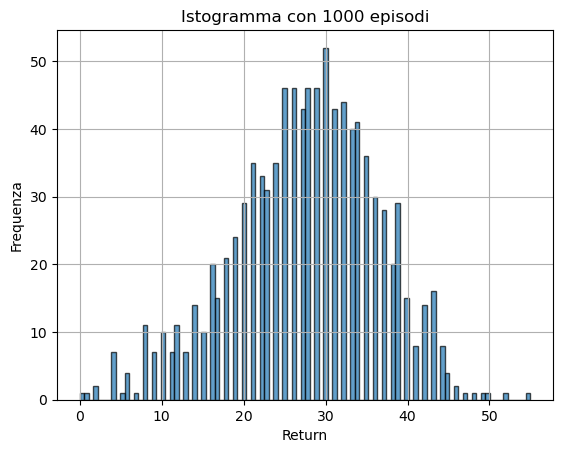

In [46]:
plt.hist(returns, bins=100, alpha=0.7, edgecolor="black")
plt.xlabel("Return")
plt.ylabel("Frequenza")
plt.title(f"Istogramma con 1000 episodi")
plt.grid(True)
plt.show()

In [38]:
print("Valore atteso del return: "+str(np.mean(returns)))
print("Valore minimo del return: "+str(np.min(returns)))
print("Valore massimo del return: "+str(np.max(returns)))

Valore atteso del return: 26.895
Valore minimo del return: 0
Valore massimo del return: 52
